# Classification

Is the second most popular supervised learning task.

# MNIST

In this project we will be using **MNIST** dataset, that contains 70 000 images of handwritten digits. Each picture labeled with integer it represents.

It's often called the "Hello World!" of Machine Learning.

**SKlearn** provides simple fetching of popular datasets:

In [18]:
from turtledemo import forest

from sklearn.datasets import fetch_openml
import numpy as np
from streamlit import title
from sympy.printing.pretty.pretty_symbology import line_width

mnist = fetch_openml("mnist_784", version=1, as_frame=False) # https://stackoverflow.com/questions/67544370/keyerror-while-fetching-mnist-data
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

> `fetch_openml()` by default returns DataFrame on 12.05.2025, set `as_frame=False` to get NumPy array.

- DESCR key describing the dataset
- A data key containing an array with one row per instance and one column per
feature
- A target key containing an array with the labels

In [19]:
X: np.ndarray = mnist["data"]
y: np.ndarray = mnist["target"]
print(X.shape, y.shape)

(70000, 784) (70000,)


Wow! Each integer has 784 features, that's because each picture contains of $ 28 \times 28 $ pixels. And each feature value represents intensity, from 0 *(white)* to 255 *(black)*

To be able to display pixels, you need to reshape vector to a $ 28 \times 28 $ array and display in **MatPlotLib Imshow** that allows to create pictures from 2d arrays.


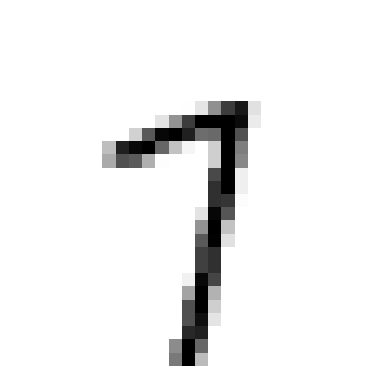

In [20]:
import matplotlib.pyplot as plt

some_digit = X[42]
some_digit_image = some_digit.reshape(28, 28)

some_digit_label = y[42]

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


Looks like 1 or 7. Let's check it's label:

In [21]:
print(some_digit_label)
print(type(some_digit_label))

7
<class 'str'>


That's 7! But label type is string, let's parce it to integer.

In [22]:
y = y.astype(np.uint8)

But firstly, let's create test and train sets. The **MNIST** dataset is already shuffled and easily can be split into 60k length train and 10k length test sets.

In [23]:
X_train, X_test = X[:60_000], X[60_000:]
y_train, y_test = y[:60_000], y[60_000:]

# Training a Binary Classifier

Let's break down this problem to a simpler one, binary classifier. That is capable of distinguishing just two cases - **8** and **not 8**.

Let's take every vector that represents 8:

In [24]:
y_train_8 = y_train == 8 # [False, True, False, False]
y_test_8 = y_test == 5

y_train_8

array([False, False, False, ..., False, False,  True], shape=(60000,))

Let's pick a classifier and train it. We will start with **Stochastic Gradient Descent** using Sklearn **SGQClassifier**. The classifier is capable dealing with large dataset effectively. Because it's deal with training instances independently *(which is well suited for **online learning**)*.

In [25]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train_8)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [26]:
k = 20

results = sgd.predict([x for x in X_train[:k]])
labels = y_train[:k]

for i in range(k):
    print(f"Label: {labels[i]} Result: {results[i]}")

Label: 5 Result: False
Label: 0 Result: False
Label: 4 Result: False
Label: 1 Result: False
Label: 9 Result: False
Label: 2 Result: False
Label: 1 Result: False
Label: 3 Result: False
Label: 1 Result: False
Label: 4 Result: False
Label: 3 Result: False
Label: 5 Result: True
Label: 3 Result: False
Label: 6 Result: False
Label: 1 Result: False
Label: 7 Result: False
Label: 2 Result: False
Label: 8 Result: True
Label: 6 Result: False
Label: 9 Result: False


As we can see, model correctly guessed one 8, but made mistake classifying 5 as an 8.

# Performance Measures

## Self implemented **Cross-Validation**

If you need more control over your cross cal, you can implement it with your own hand:

In [27]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_8):
    train_X, train_y = X_train[train_index], y_train_8[train_index]
    test_X, test_y = X_train[test_index], y_train_8[test_index]

    sgd_clf: SGDClassifier = clone(sgd)
    sgd_clf.fit(train_X, train_y)
    results = sgd_clf.predict(test_X)

    correct = 0
    for i, res in enumerate(results):
        if res == test_y[i]:
            correct += 1

    print(correct / len(results))

0.9365
0.92665
0.8386


Let's use known before `cross_val` from **SKLearn** to evaluate how our model perform.

In [28]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd, X_train, y_train_8, cv=3, scoring="accuracy")

array([0.909  , 0.9286 , 0.88285])

Wow! Over 90% accuracy, that's impressing. Until you realise that chance of guessing is one number out of 10 is 8 90%.

Let's try to implement a very dumb model to compare results.

In [29]:
from sklearn.base import BaseEstimator

class Not8Classifier(BaseEstimator):
    def fit(self, X, y):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool) # Array of False values

not8 = Not8Classifier()

cross_val_score(not8, X_train, y_train_8, cv=3, scoring="accuracy")

array([0.9039 , 0.9031 , 0.90045])

That's right, 90% accuracy, this is simply because only about 10% of the images are 8's. So you will always be right about 90& of thet time.

This demonstrates why **accuracy** isn't preferred perf. measure for classifying. Especially with **skewed** datasets, where some data appear more frequently that the others.

## Confusion Matrix

This approach is a much better way. The general idea is to count the number of times instances of class A are
classified as class

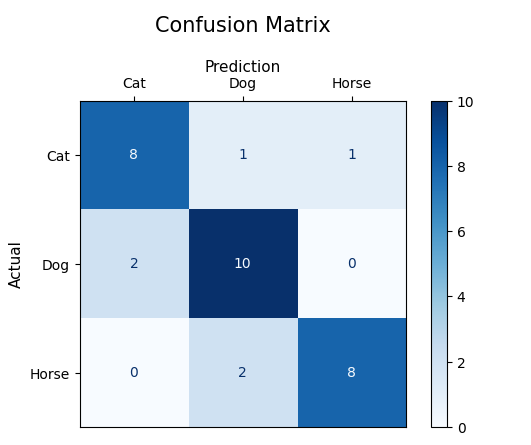

In [30]:
from sklearn.model_selection import cross_val_predict

y_train_predict = cross_val_predict(sgd, X_train, y_train_8, cv=3)

from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_8, y_train_predict)

array([[50006,  4143],
       [ 1448,  4403]])

Only two rows, because our classifier can only return boolean prediction.

Each row in a confusion matrix represents an **actual class**, while each column represents a **predicted class**. The first row of this matrix considers non-5 images _(the negative class)_: 53,057 of them were correctly classified as non-5s _(they are called true
negatives)_, while the remaining 1,522 were wrongly classified as 5s _(false positives)_.
The second row considers the images of 5s _(the positive class)_: 1,325 were wrongly
classified as non-5s _(false negatives)_

If we had a perfect model, every cell in confusion matrix would be full of zeros, except for main diagonal.

In [31]:
y_train_perfect_predictions = y_train_8 # A Perfect model

confusion_matrix(y_train_8, y_train_perfect_predictions)

array([[54149,     0],
       [    0,  5851]])

Our confusion matrix figure: _(taken from the book)_
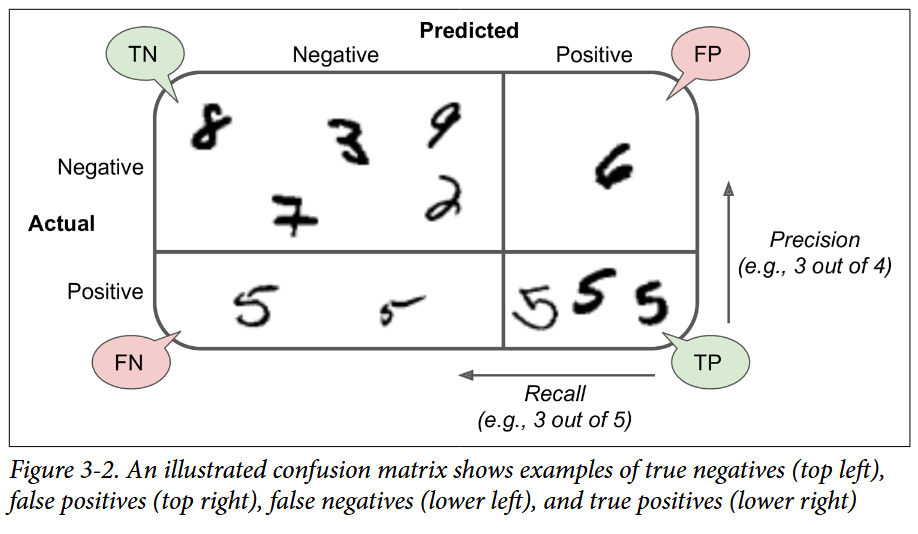

## Precision and Recall

Precision - how precise your models.
> Out of predicted 8s, how many were correct?

Recall - ratio of how many 8s your model found.
> How many of the real 8s the model found.


In [32]:
from sklearn.metrics import recall_score, precision_score

print(precision_score(y_train_8, y_train_predict)) # 4403 / (4403 + 1448) | from the conf. matrix
print(recall_score(y_train_8, y_train_predict))

0.515211794991809
0.7525209365920356


As we can see, our predictor doesn't look shiny at all. It gets only 51% percent of 8s correctly, and classified as 8 only 75% of the 8s.

If we combine these two metrix into one, we will get **F1 Score** - _harmonic mean_
$$
\begin{align}
F_1 &= 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{TP}{TP + \frac{FN + FP}{2}}
\end{align}
$$

In [33]:
from sklearn.metrics import f1_score

print(f1_score(y_train_8, y_train_predict))

0.6116552059456831


Regular mean treats all values equally, the harmonic mean gives more weight to low values. To get high **F1 Score**, both precision and recall must be high.

## Precision and Recall Trade-off

Usually, if model precision is high, it's recall low and backwards. But, we can explore how these two metrics depending on each other.

Almost every linear classification models has `decision_function()` method, which returns score for each instance. Then model apply it to learned threshold and predict class that instance belongs to.

**Scikit-Learn** doesn't let user set threshold directly, but we can get scores of each instance via `decision_function()` and compare them with our threshold.

In [34]:
y_scores = sgd.decision_function([some_digit])
print(y_scores)

threshold = 0
some_digit_prediction = y_scores > threshold
print(some_digit_prediction)

[-3972.75646463]
[False]


In [35]:
threshold = -7000
some_digit_prediction = y_scores > threshold
some_digit_prediction

array([ True])

Results confirm that **lowering threshold** decreases **precision**.

But how do we decide which threshold to use? We can build plot that shows precision and recall curve using **SKLearn**. But firstly we need to get score of each training set instance, let's use cross validation.

In [36]:
y_scores = cross_val_predict(sgd, X_train, y_train_8, cv=3, method="decision_function")

Then we use `prfecision_recall_curve()` to compute precision and recall for **all possible threshold**.

In [37]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_8, y_scores)

Now we have all information to build precision recall curve.

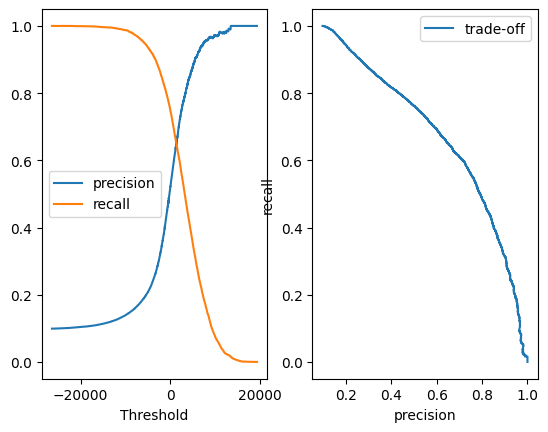

In [38]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    fig, ax = plt.subplots(1, 2, )
    ax[0].plot(thresholds[1000:], precisions[1000:-1], label="precision")
    ax[0].plot(thresholds[1000:], recalls[1000:-1], label="recall")
    ax[0].set(xlabel="Threshold")
    ax[0].legend()

    ax[1].plot(precisions, recalls, label="trade-off")
    ax[1].legend()
    ax[1].set(xlabel="precision", ylabel="recall")

    plt.show()

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)

As we can see, recall starts to fall sharply at 60% precision.
Suppose you're aim for 90% precision. If you look on a first plot, you can note that we need to aim at threshold around 8000.
To be precise, we can use `np.argmax()` function to search the lowest threshold that gives us at least 90% precision.

In [39]:
threshold_90_precision_idx = np.argmax(precisions >= 0.9)
threshold_90_precision = thresholds[threshold_90_precision_idx]
threshold_90_precision

np.float64(5558.688951079276)

In [40]:
y_train_predictions_90 = y_scores > threshold_90_precision
print(precision_score(y_train_8, y_train_predictions_90))
print(recall_score(y_train_8, y_train_predictions_90))

0.9007820136852395
0.3149888907878995


Great! Now we have 90% accurate models, but our recall is pretty low. So don't hurry.

# The ROC Curve

Let's plot the ROC Curve, to see how well model separates `True` and `False` classes, the ratio of *true positive rate* and *false negative rate*.

np.int64(357)

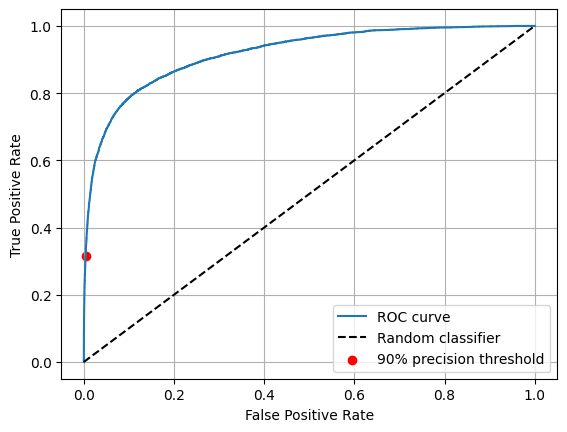

In [41]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_8, y_scores)
threshold_90_precision_idx = (thresholds <= threshold_90_precision).argmax()

def plot_roc_curve(fpr, tpr) -> None:
    plt.plot(fpr, tpr, label="ROC curve")
    plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
    plt.scatter([fpr[threshold_90_precision_idx]], [tpr[threshold_90_precision_idx]], color="red", label="90% precision threshold")
    plt.ylabel("True Positive Rate")
    plt.xlabel("False Positive Rate")
    plt.legend()
    plt.grid(True)

plot_roc_curve(fpr, tpr)
threshold_90_precision_idx

Higher curve - better model. Diagonal line is a pure random model.

Is curve angle is 90 degrees, the model is perfect.

Also, we can see similar trade-off between these two metrics.

Another way to evaluate ROC curve, is to compute its area under the curve _(AUC)_. **SKLearn** provides `roc_auc_score` function for this.

In [42]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_train_8, y_scores)
auc_score

0.9192599874103056

As we can see, our binary classifier is pretty good, the curve is pretty far from pure random and the AUC is excellent.
Random model would achieve 0.5 score, perfect - 1.0

As we know, that True class is much rarer than the False class, we should look closer to Precision/Recall curve rather than on ROC. Because ROC can confuse us that the model is efficient.

Let's train **RandomForestClassifier**, and compare its **PR curve** and **F1**

In [43]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_8, cv=3, method="predict_proba")
y_probas_forest[:3]

array([[0.98, 0.02],
       [1.  , 0.  ],
       [0.96, 0.04]])

Since **RandomForestClassifier** doesn't have `decision_function()` *(due to the way it works, more in Jupyter note about trees)*, we use `predict_proba()` which returns _probabilities_ for each class. As you can see in the output _(rows are predictions, the first col is a Negative class, last col is a Positive Class)_.

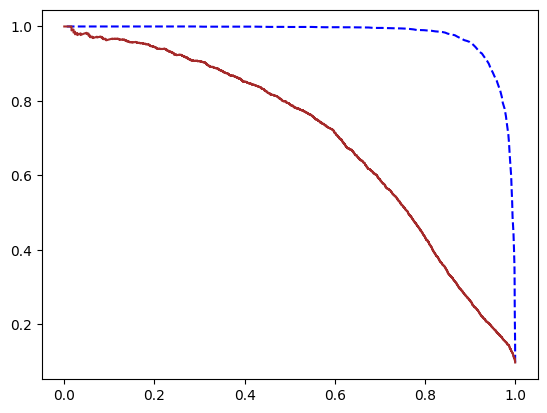

In [44]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_8, y_scores_forest)

plt.plot(recalls_forest, precisions_forest, label="Random forest classifier Precision-Recall curve", color="blue", linestyle="--")
plt.plot(recalls, precisions, label="=SGD classifier Precision-Recall curve", color="brown")
plt.show()

In [45]:
forest_predictions = y_probas_forest[:, 1] > 0.5

f1_forest_score = f1_score(y_train_8, forest_predictions)
auc_score = roc_auc_score(y_train_8, forest_predictions)
print(f1_forest_score)
print(auc_score)

0.8874646559849199
0.901853466169275


Great results! The PR curve is much closer to the right corner comparing to the SGD classifier. And scores are not too bad.

We're ready to try to detect more than just 8's

# Multiclass Classification

Add about OvR, OvA

SKLearn detects when you try to use binary classification algorithm for multiclass classification task. It automatically runs OvR or OvO, depending on the algorithm.

Let's try to train support vector classifier.

In [77]:
from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

svm_clf.predict([some_digit])

array([7], dtype=uint8)

It correctly classified our digit from the beginning as 7. This prediction actually made 45 binary predictions, one per each pair of classes.

In [47]:
some_digit_scores = svm_clf.decision_function([some_digit])
print(f"Probabilities - {some_digit_scores.round(2)}")

class_id = some_digit_scores.argmax()
print(f"Class - {svm_clf.classes_[class_id]}")

Probabilities - [[-0.29  7.19  1.77  3.78  6.12  2.83  0.72  9.3   4.8   8.29]]
Class - 7


If we call `decision_function()`, we will get each class scores. Each class score equal to number of duels it won, +- small tweak up to 0.33.

To access the model classes, call `classes_` attribute.

If you want to **force SKlearn tu yse one-versus-one or one-versus-rest strategy you can use OneVsOneClassifier or OneVsRestClassifier**.
Simply create one of these class instances and pass a classifier to its constructor.

In [81]:
from sklearn.multiclass import OneVsRestClassifier

ovr_svm_clf = OneVsRestClassifier(SVC(random_state=42))

ovr_svm_clf.fit(X_train[:2000], y_train[:2000])
print(len(ovr_svm_clf.estimators_))

print(f"Probabilities - {ovr_svm_clf.decision_function([some_digit])}")

ovr_svm_scores = cross_val_score(ovr_svm_clf, X_train, y_train, cv=3, scoring="accuracy") # Lower X_train instances amount to decrease time running
print(ovr_svm_scores.round(2))

10
Probabilities - [[-1.82628206 -1.01587864 -1.59967966 -1.73397959 -1.42897807 -1.23482579
  -1.71391448  0.60527335 -1.4220273  -0.9999515 ]]
[0.98 0.97 0.97]


As we can see, our model trained 10 binary classifiers. As in OVR strategy.

If we look closer to predicted scores, we can see that the model isn't sure about its decisions. The 7s class scores is only 0.6, while the others aren't really far. _(actually my results aren't really match :) )_

Also, we can try to slightly improve results, by scaling our feature:

In [82]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

ovr_scaling_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("predict", ovr_svm_clf)
])

scaler = StandardScaler()
ovr_svm_scores = cross_val_score(ovr_scaling_pipeline, X_train, y_train, cv=3, scoring="accuracy") # Lower X_train instances amount to decrease time running
ovr_svm_scores.round(2)

array([0.96, 0.96, 0.96])

But, this didn't help us. My results don't match with book ones. But you got the idea.

## Error Analysis